C:\Users\User\AppData\Local\Temp\ipykernel_18628\3348649410.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('total.csv')


Original Class Distribution:
 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Class Distribution After Conversion:
 Label
0    2273097
1     557647
Name: count, dtype: int64

Class Distribution After SMOTE:
0    2273097
1    1115294
Name: count, dtype: int64

Evaluating with 1% of attack samples

Class Distribution:
0    2273097
1      11152
Name: count, dtype: int64

🔹 **Logistic Regression Performance Metrics:**
Precision: 0.9478
Recall: 0

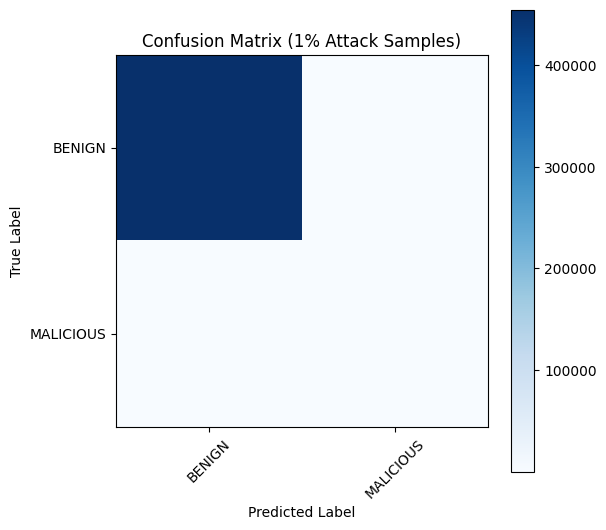


Evaluating with 5% of attack samples

Class Distribution:
0    2273097
1      55764
Name: count, dtype: int64

🔹 **Logistic Regression Performance Metrics:**
Precision: 0.9535
Recall: 0.4181
F1-Score: 0.5814
Matthews Correlation Coefficient: 0.6264
Balanced Accuracy: 0.7088

🔹 **Confusion Matrix:**
[[454404    227]
 [  6483   4659]]


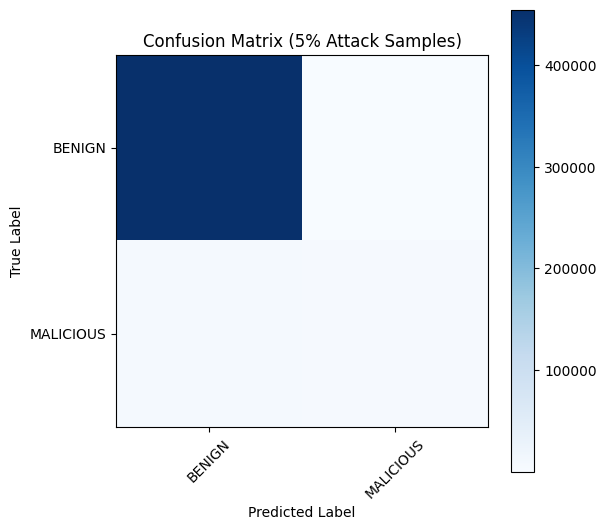


Evaluating with 10% of attack samples

Class Distribution:
0    2273097
1     111529
Name: count, dtype: int64

🔹 **Logistic Regression Performance Metrics:**
Precision: 0.9588
Recall: 0.4333
F1-Score: 0.5969
Matthews Correlation Coefficient: 0.6347
Balanced Accuracy: 0.7162

🔹 **Confusion Matrix:**
[[454042    418]
 [ 12731   9735]]


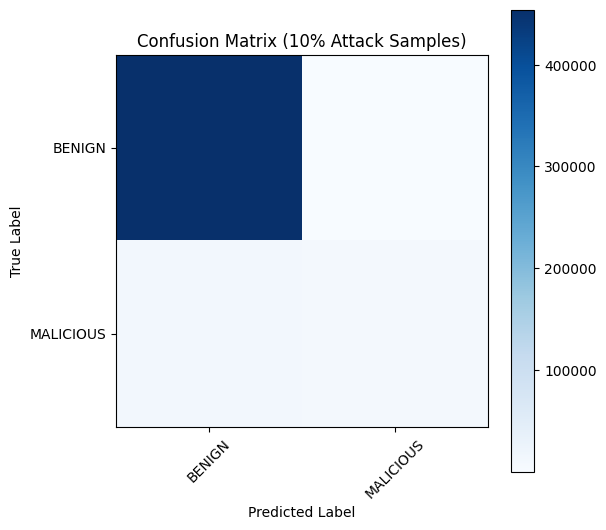


Evaluating with 30% of attack samples

Class Distribution:
0    2273097
1     334588
Name: count, dtype: int64

🔹 **Logistic Regression Performance Metrics:**
Precision: 0.7614
Recall: 0.7322
F1-Score: 0.7465
Matthews Correlation Coefficient: 0.7101
Balanced Accuracy: 0.8492

🔹 **Confusion Matrix:**
[[439106  15385]
 [ 17953  49093]]


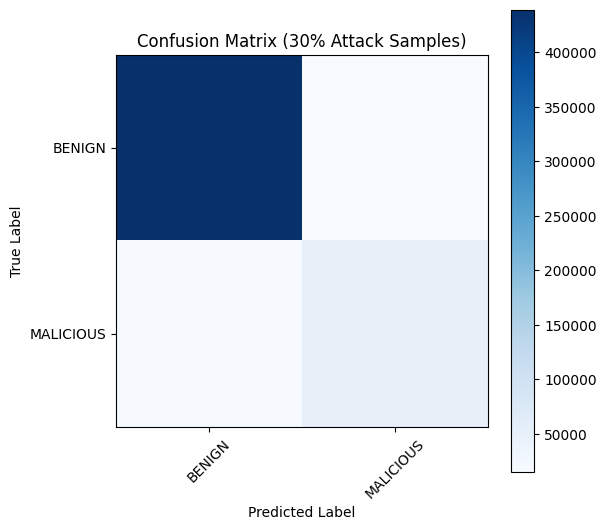


Evaluating with 60% of attack samples

Class Distribution:
0    2273097
1     669176
Name: count, dtype: int64

🔹 **Logistic Regression Performance Metrics:**
Precision: 0.8479
Recall: 0.7370
F1-Score: 0.7886
Matthews Correlation Coefficient: 0.7345
Balanced Accuracy: 0.8490

🔹 **Confusion Matrix:**
[[436490  17741]
 [ 35306  98918]]


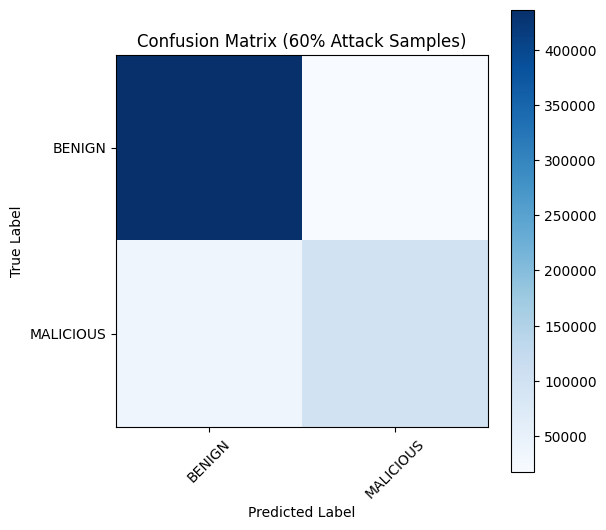


Evaluating with 80% of attack samples

Class Distribution:
0    2273097
1     892235
Name: count, dtype: int64

🔹 **Logistic Regression Performance Metrics:**
Precision: 0.8792
Recall: 0.7392
F1-Score: 0.8031
Matthews Correlation Coefficient: 0.7400
Balanced Accuracy: 0.8497

🔹 **Confusion Matrix:**
[[436673  18113]
 [ 46496 131785]]


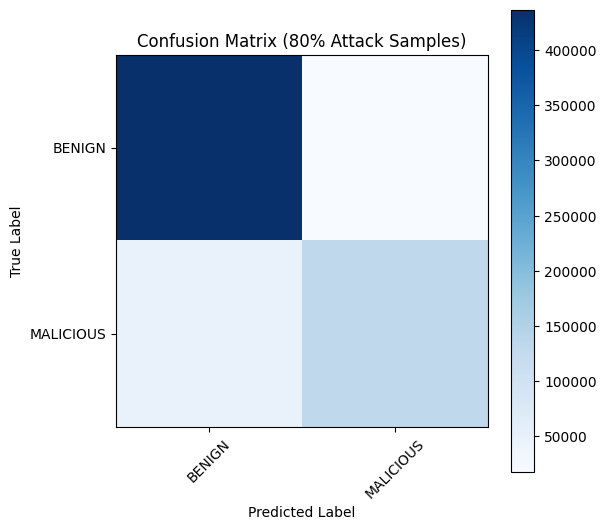


Evaluating with 100% of attack samples

Class Distribution:
0    2273097
1    1115294
Name: count, dtype: int64

🔹 **Logistic Regression Performance Metrics:**
Precision: 0.8995
Recall: 0.7413
F1-Score: 0.8128
Matthews Correlation Coefficient: 0.7402
Balanced Accuracy: 0.8503

🔹 **Confusion Matrix:**
[[435392  18536]
 [ 57874 165877]]


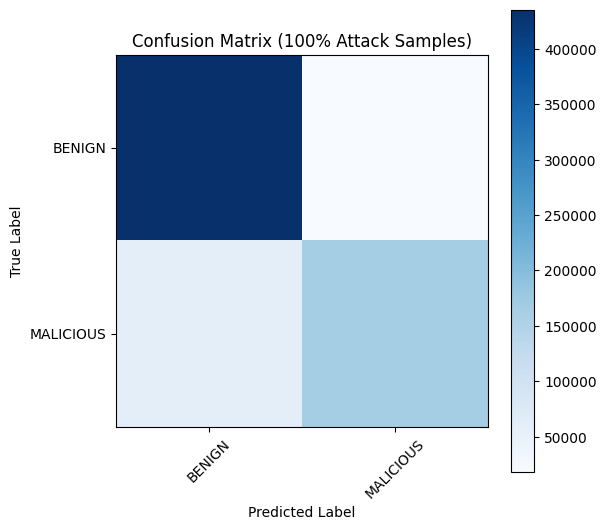



🔹🔹🔹 **Final Comparison of Logistic Regression Performance** 🔹🔹🔹
Attack%    Precision    Recall     F1         MCC        Bal_Acc   
1          0.9478       0.4190     0.5811     0.6291     0.7094    
5          0.9535       0.4181     0.5814     0.6264     0.7088    
10         0.9588       0.4333     0.5969     0.6347     0.7162    
30         0.7614       0.7322     0.7465     0.7101     0.8492    
60         0.8479       0.7370     0.7886     0.7345     0.8490    
80         0.8792       0.7392     0.8031     0.7400     0.8497    
100        0.8995       0.7413     0.8128     0.7402     0.8503    


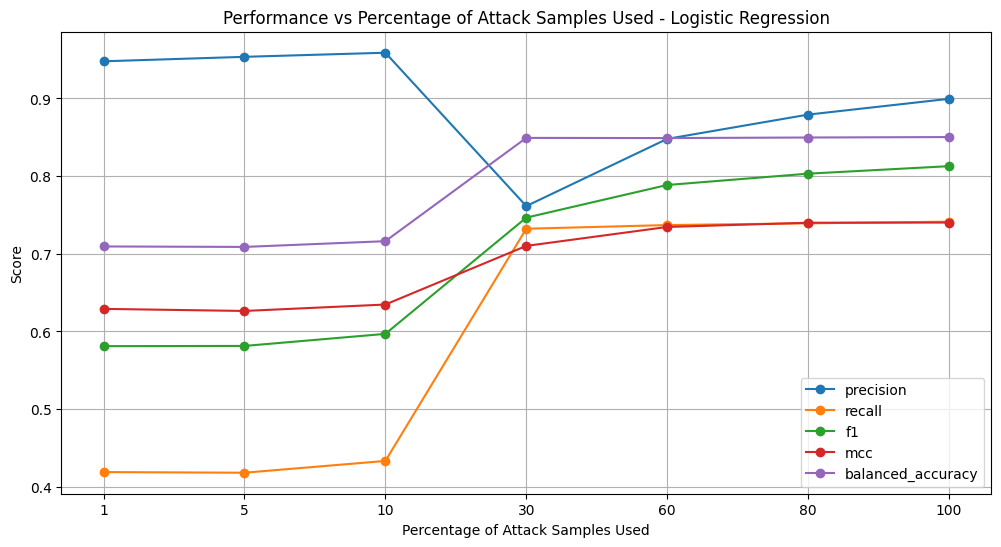

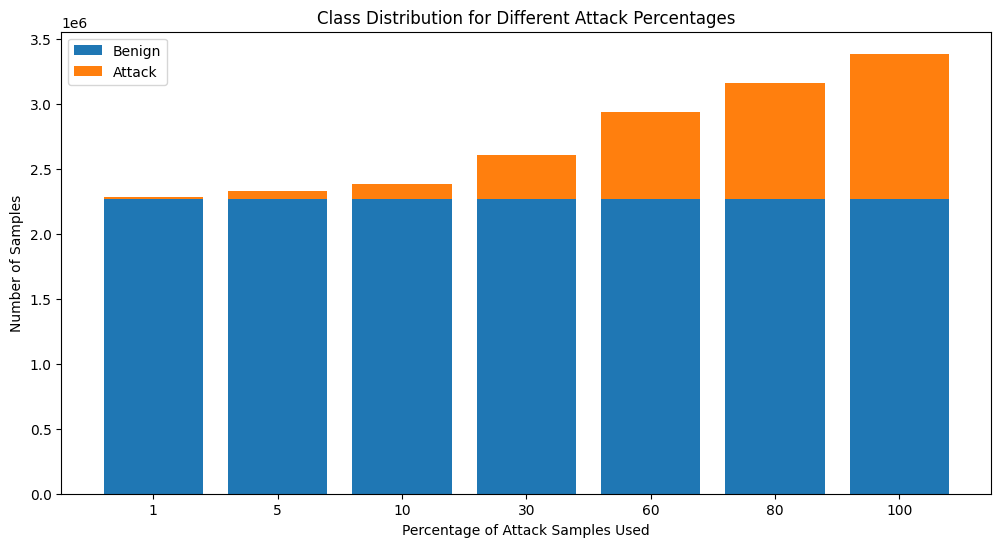

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                           confusion_matrix, matthews_corrcoef, 
                           balanced_accuracy_score)
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('total.csv')

# Define selected features
selected_columns = [
    ' Avg Fwd Segment Size', ' Fwd Packet Length Mean', ' Fwd Packet Length Max', 
    ' Subflow Fwd Bytes', ' Average Packet Size', 'Total Length of Fwd Packets', 
    ' Packet Length Std', ' Packet Length Variance', ' Bwd Packet Length Mean', 
    ' PSH Flag Count', 'Init_Win_bytes_forward', ' Bwd Packet Length Std', 
    'Bwd Packet Length Max', ' Max Packet Length', ' Fwd Header Length', 
    ' Packet Length Mean', ' Total Length of Bwd Packets', ' Bwd Packets/s', 
    ' act_data_pkt_fwd', ' Init_Win_bytes_backward', 'Flow Bytes/s', 
    ' Subflow Bwd Bytes', ' Bwd Header Length', ' ACK Flag Count', ' Fwd IAT Std',' Label'
]

target_column = ' Label'  
print("Original Class Distribution:")
print(df[target_column].value_counts())

# Ensure all selected columns exist
missing_columns = [col for col in selected_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

# Keep only selected features and target variable
df = df[selected_columns]

# Convert target labels
df[' Label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Proceed with the rest of the code
print("\nClass Distribution After Conversion:")
print(df[' Label'].value_counts())

# Separate features and target
X = df.drop(columns=[' Label'])
y = df[' Label'].values

# Handle missing & infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# Apply imputation before SMOTE
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# --- Manual SMOTE Implementation ---
def smote(X, y, k=5, oversampling_ratio=1.0):
    # Identify the minority class
    unique, counts = np.unique(y, return_counts=True)
    minority_class = unique[np.argmin(counts)]  # Find minority class
    X_minority = X[y == minority_class]
    n_minority = X_minority.shape[0]

    # Compute the number of synthetic samples needed
    n_synthetic = int(n_minority * oversampling_ratio)

    # Initialize an array to store synthetic samples
    synthetic_samples = np.zeros((n_synthetic, X.shape[1]))

    # Use KNN to find neighbors
    knn = NearestNeighbors(n_neighbors=min(k, n_minority))  # Avoid errors if samples are too few
    knn.fit(X_minority)

    # Generate synthetic samples
    for i in range(n_synthetic):
        # Randomly select a minority sample
        idx = np.random.randint(0, n_minority)
        sample = X_minority[idx]

        # Find k-nearest neighbors
        _, neighbors = knn.kneighbors(sample.reshape(1, -1))

        # Select one of the neighbors randomly
        neighbor_idx = np.random.choice(neighbors[0])
        neighbor = X_minority[neighbor_idx]

        # Create synthetic sample
        diff = neighbor - sample
        synthetic_sample = sample + np.random.rand() * diff
        synthetic_samples[i] = synthetic_sample

    # Combine original and synthetic samples
    X_resampled = np.vstack((X, synthetic_samples))
    y_resampled = np.hstack((y, np.full(n_synthetic, minority_class)))

    return X_resampled, y_resampled

# Apply SMOTE to create balanced dataset
X_resampled, y_resampled = smote(X, y, oversampling_ratio=1.0)

# Check the class distribution after SMOTE
print("\nClass Distribution After SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Function to create datasets with different percentages of attack samples
def create_dataset_with_attack_percentage(X_full, y_full, percentage):
    # Split into benign and attack
    X_benign = X_full[y_full == 0]
    y_benign = y_full[y_full == 0]
    X_attack = X_full[y_full == 1]
    y_attack = y_full[y_full == 1]
    
    # Calculate number of attack samples to use
    n_attack_total = len(X_attack)
    n_attack_use = int(n_attack_total * percentage / 100)
    
    # Randomly select attack samples
    attack_indices = np.random.choice(n_attack_total, n_attack_use, replace=False)
    X_attack_sampled = X_attack[attack_indices]
    y_attack_sampled = y_attack[attack_indices]
    
    # Combine with all benign samples
    X_balanced = np.vstack((X_benign, X_attack_sampled))
    y_balanced = np.hstack((y_benign, y_attack_sampled))
    
    return X_balanced, y_balanced

# Define attack percentages to test
attack_percentages = [1, 5, 10, 30, 60, 80, 100]

# Dictionary to store results
results = {}

for percentage in attack_percentages:
    print(f"\n{'='*50}")
    print(f"Evaluating with {percentage}% of attack samples")
    print(f"{'='*50}")
    
    # Create dataset with specific percentage of attack samples
    X_percentage, y_percentage = create_dataset_with_attack_percentage(X_resampled, y_resampled, percentage)
    
    # Check the class distribution
    class_distribution = pd.Series(y_percentage).value_counts()
    print("\nClass Distribution:")
    print(class_distribution)
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_percentage, y_percentage, test_size=0.2, random_state=42)
    
    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Initialize and train Logistic Regression classifier
    lr = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_train_scaled, y_train)
    y_pred = lr.predict(X_test_scaled)
    
    # Compute Performance Metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    
    # Store results
    results[percentage] = {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mcc': mcc,
        'balanced_accuracy': bal_acc,
        'class_distribution': class_distribution.to_dict()
    }
    
    # Print Performance Metrics
    print("\n🔹 **Logistic Regression Performance Metrics:**")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    
    # Print Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("\n🔹 **Confusion Matrix:**")
    print(conf_matrix)

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix ({percentage}% Attack Samples)')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['BENIGN', 'MALICIOUS'], rotation=45)
    plt.yticks(tick_marks, ['BENIGN', 'MALICIOUS'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Compare results
print("\n\n🔹🔹🔹 **Final Comparison of Logistic Regression Performance** 🔹🔹🔹")
print("{:<10} {:<12} {:<10} {:<10} {:<10} {:<10}".format(
    "Attack%", "Precision", "Recall", "F1", "MCC", "Bal_Acc"))
for percentage, metrics in results.items():
    print("{:<10} {:<12.4f} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        str(percentage),
        metrics['precision'],
        metrics['recall'],
        metrics['f1'],
        metrics['mcc'],
        metrics['balanced_accuracy']))

# Plot comparison
metrics_to_plot = ['precision', 'recall', 'f1', 'mcc', 'balanced_accuracy']
x_labels = [str(p) for p in attack_percentages]

plt.figure(figsize=(12, 6))
for metric in metrics_to_plot:
    values = [results[p][metric] for p in attack_percentages]
    plt.plot(x_labels, values, marker='o', label=metric)

plt.title('Performance vs Percentage of Attack Samples Used - Logistic Regression')
plt.xlabel('Percentage of Attack Samples Used')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# Plot class distribution for each percentage
plt.figure(figsize=(12, 6))
attack_counts = []
benign_counts = []

for percentage in attack_percentages:
    dist = results[percentage]['class_distribution']
    benign_counts.append(dist[0])
    attack_counts.append(dist[1])

plt.bar([str(p) for p in attack_percentages], benign_counts, label='Benign')
plt.bar([str(p) for p in attack_percentages], attack_counts, bottom=benign_counts, label='Attack')
plt.title('Class Distribution for Different Attack Percentages')
plt.xlabel('Percentage of Attack Samples Used')
plt.ylabel('Number of Samples')
plt.legend()
plt.show()